In [48]:
import uproot
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
import os

In [45]:
def save_figure(fig, figname, outdir=''):
    outname=os.path.join(outdir, f"{figname}.png")
    fig.savefig(outname, bbox_inches='tight', format='png')
    print(f'plot saved to {outname}')
    plt.close(fig)

In [65]:
def plot_combine_variations(root_file_path, process_name, systematic_name, chan):
    """
    Opens a Combine ROOT file and plots the nominal, Up, and Down variations.
    
    Parameters:
    - root_file_path: Path to the .root file (e.g., 'LOtoNLOuncert_plots/TESTING-ttbar-ee_2b_2j_mllbb.root')
    - process_name: The base process name in the root file (e.g., 'tt_sm')
    - systematic_name: The name of the shape systematic (e.g., 'LOtoNLO2j')
    """
    # 1. Open the file using uproot
    with uproot.open(root_file_path) as f:
        
        # Construct the internal ROOT key names
        nominal_key = f"{process_name}"
        up_key = f"{process_name}_{systematic_name}Up"
        down_key = f"{process_name}_{systematic_name}Down"
        
        # 2. Extract the histograms into uproot/hist-compatible objects
        # Using .to_hist() converts the uproot TH1 into a standard scikit-hep hist object
        try:
            h_nom = f[nominal_key].to_hist()
            h_up = f[up_key].to_hist()
            h_down = f[down_key].to_hist()
        except KeyError as e:
            print(f"Error: Could not find one of the keys in the ROOT file. {e}")
            print("Available keys inside file:", f.keys())
            return

    # 3. Set up the figure with Main and Ratio subplots
    hep.style.use("CMS")
    fig, (ax, rax) = plt.subplots(
        nrows=2, ncols=1, figsize=(10, 10),
        gridspec_kw={'height_ratios': (4, 1), 'hspace': 0.05},
        sharex=True
    )
    
    # ---------------------------------------------------------
    # MAIN PLOT: Absolute Yields
    # ---------------------------------------------------------
    # Plot nominal as a solid black step line
    hep.histplot(h_nom, label="Nominal", color="black", linewidth=2, ax=ax, yerr=False)
    
    # Plot variations as dashed red (Up) and blue (Down) lines
    hep.histplot(h_up, label=f"{systematic_name} Up", histtype="step", ax=ax, yerr=False)
    hep.histplot(h_down, label=f"{systematic_name} Down",  histtype="step", ax=ax, yerr=False)
    
    ax.set_ylabel("Events / Bin")
    ax.legend(loc="upper right")
    ax.set_title(f"{chan} - {systematic_name}")
    
    # ---------------------------------------------------------
    # RATIO PLOT: Variation / Nominal
    # ---------------------------------------------------------
    # Extract raw numpy arrays to calculate ratios manually
    nom_vals = h_nom.values()
    
    # Safe division guard against zero-yield bins
    safe_nom = np.where(nom_vals > 0, nom_vals, 1.0)
    
    ratio_up = h_up.values() / safe_nom
    ratio_down = h_down.values() / safe_nom
    
    # Get bin edges for the rax.stairs step plotting
    bin_edges = h_nom.axes[0].edges
    
    # Plot the ratio lines
    hep.histplot(
        ratio_up,
        yerr=False,
        xerr=True,
        markersize=8,
        histtype='errorbar',
        ax=rax,
        label='Up'
    ) 
    
    hep.histplot(
        ratio_down,
        yerr=False,
        xerr=True,
        markersize=8,
        histtype='errorbar',
        ax=rax,
        label='Down'
    ) 
        
    # rax.stairs(ratio_up, edges=bin_edges, linestyle="-", linewidth=2)
    # rax.stairs(ratio_down, edges=bin_edges, linestyle="-", linewidth=2)
    
    # Styling the ratio canvas
    rax.axhline(y=1.0, color="gray", linestyle="-", alpha=0.7)
    rax.set_ylabel("Var / Nom", fontsize=16)
    rax.set_ylim([0.5, 1.5])  # Adjust depending on how large your variations are
    
    ax.set_xlabel("")
    # Apply standard hep grid/labels if desired
    ax.grid(True, linestyle=":", alpha=0.5)
    rax.grid(True, linestyle=":", alpha=0.5)
    
    # plt.tight_layout()
    plt.show()
    
    save_figure(fig, f"{chan}_{systematic_name}", outdir='plots_CombineHists/260519_LOtoNLO/')

# Example usage:
# plot_combine_variations("LOtoNLOuncert_plots/TESTING-ttbar-ee_2b_2j_mllbb.root", "tt_sm", "LOtoNLO2j")

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


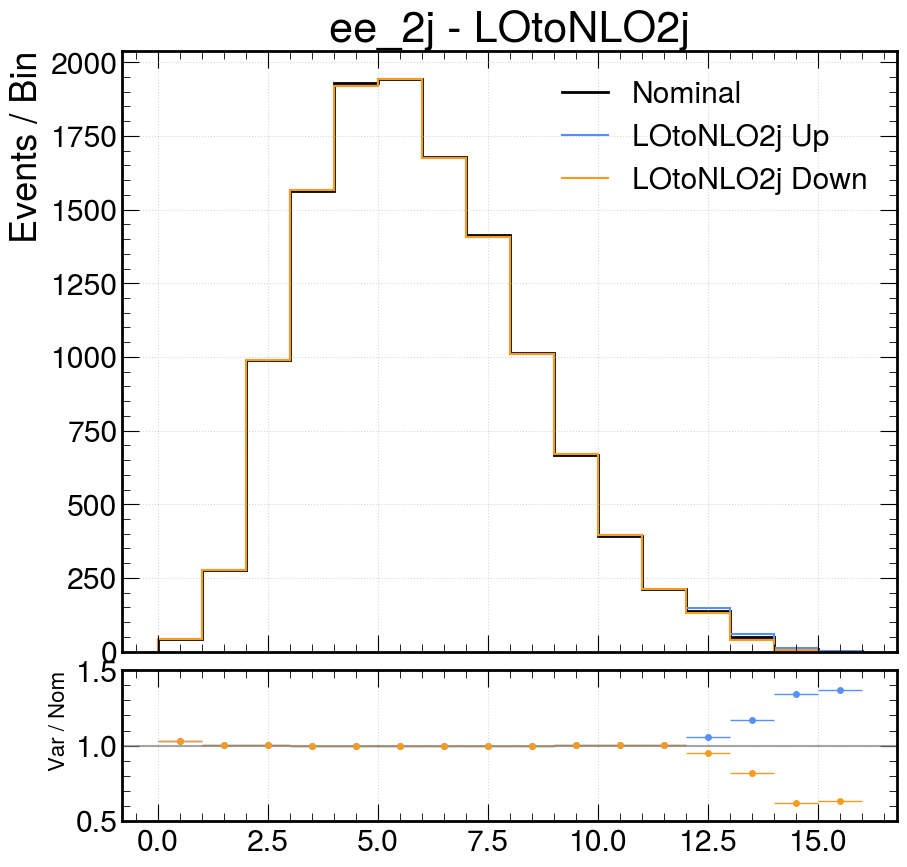

plot saved to plots_CombineHists/260519_LOtoNLO/ee_2j_LOtoNLO2j.png


In [67]:
plot_combine_variations("260519_fixLOtoNLO/TESTING-ttbar-ee_2b_2j_mllbb.root", "tt_sm", "LOtoNLO2j", "ee_2j")

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


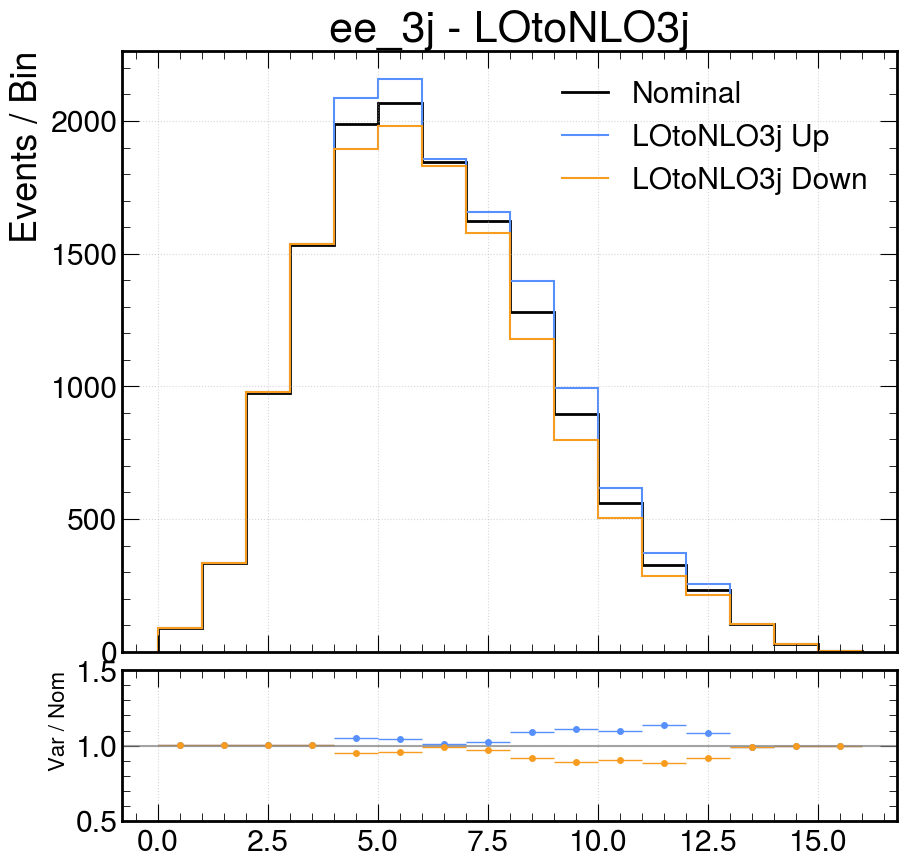

plot saved to plots_CombineHists/260519_LOtoNLO/ee_3j_LOtoNLO3j.png


In [68]:
plot_combine_variations("260519_fixLOtoNLO/TESTING-ttbar-ee_2b_3j_mllbb.root", "tt_sm", "LOtoNLO3j", "ee_3j")

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


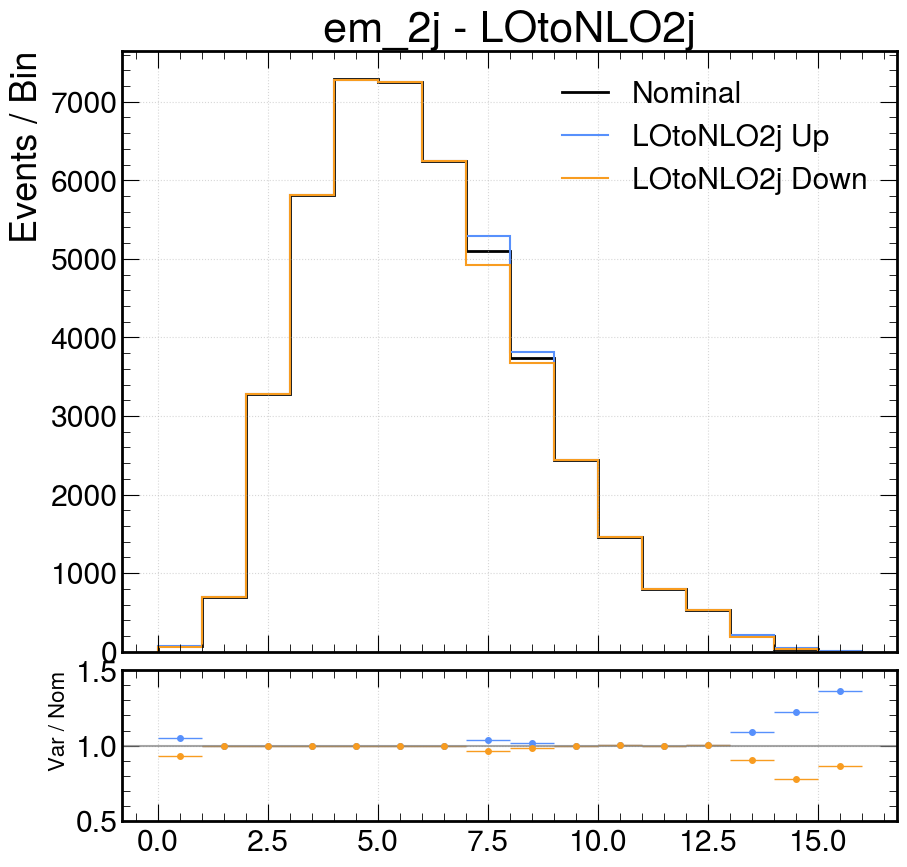

plot saved to plots_CombineHists/260519_LOtoNLO/em_2j_LOtoNLO2j.png


In [69]:
plot_combine_variations("260519_fixLOtoNLO/TESTING-ttbar-em_2b_2j_mllbb.root", "tt_sm", "LOtoNLO2j", "em_2j")

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


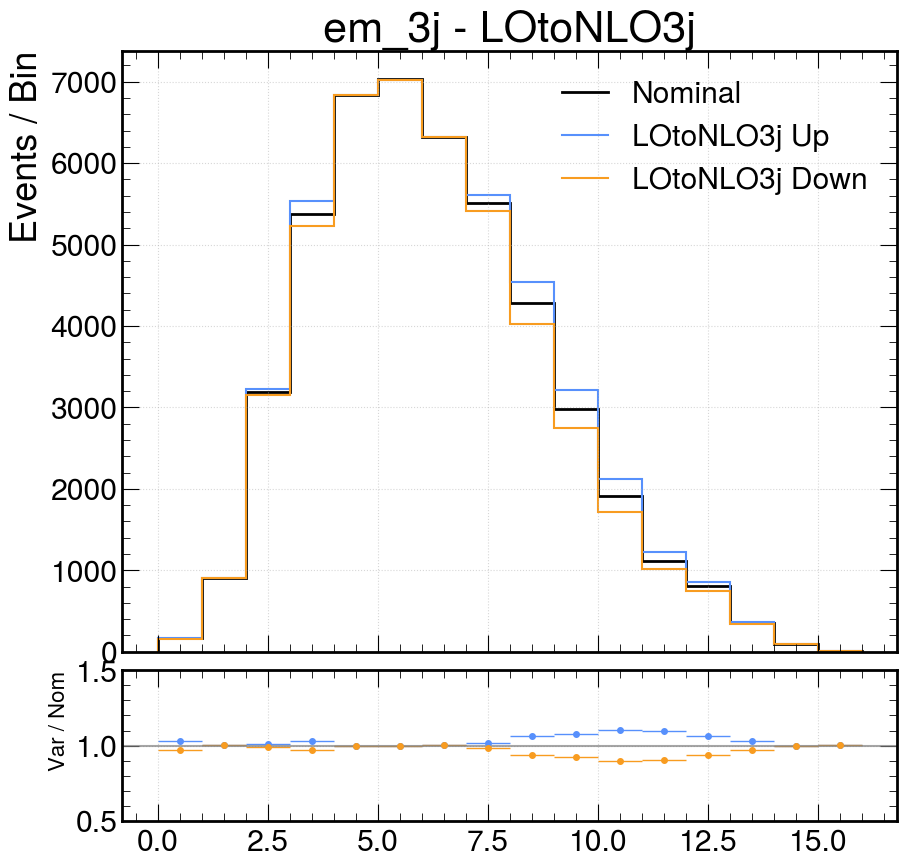

plot saved to plots_CombineHists/260519_LOtoNLO/em_3j_LOtoNLO3j.png


In [70]:
plot_combine_variations("260519_fixLOtoNLO/TESTING-ttbar-em_2b_3j_mllbb.root", "tt_sm", "LOtoNLO3j", "em_3j")

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


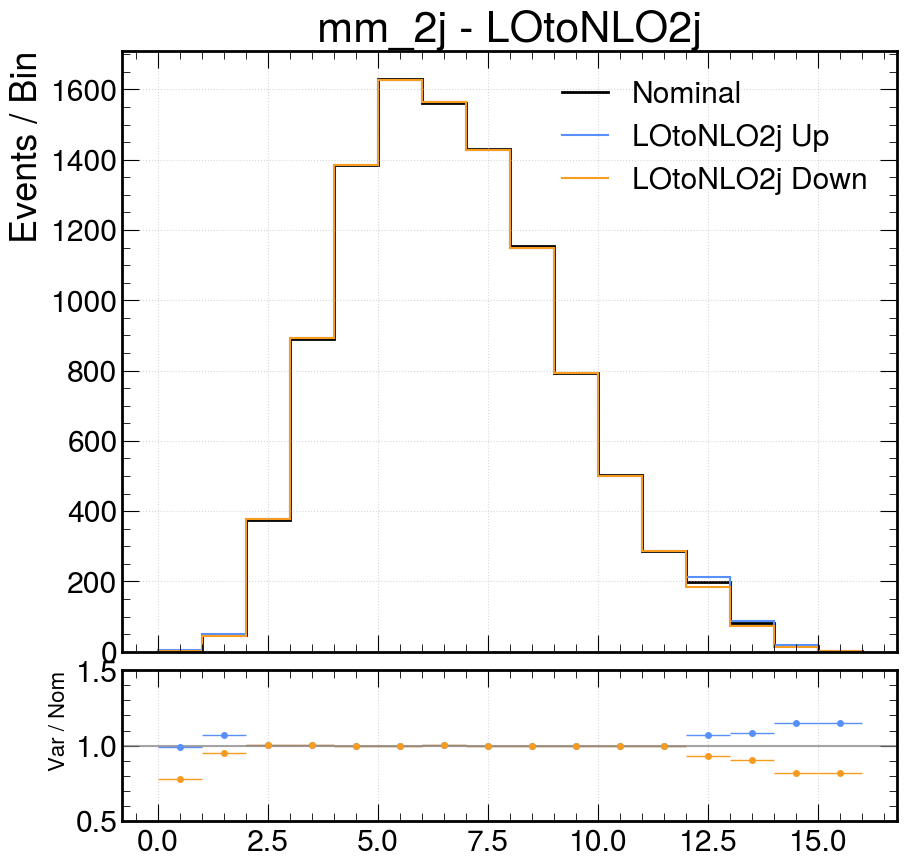

plot saved to plots_CombineHists/260519_LOtoNLO/mm_2j_LOtoNLO2j.png


In [71]:
plot_combine_variations("260519_fixLOtoNLO/TESTING-ttbar-mm_2b_2j_mllbb.root", "tt_sm", "LOtoNLO2j", "mm_2j")

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


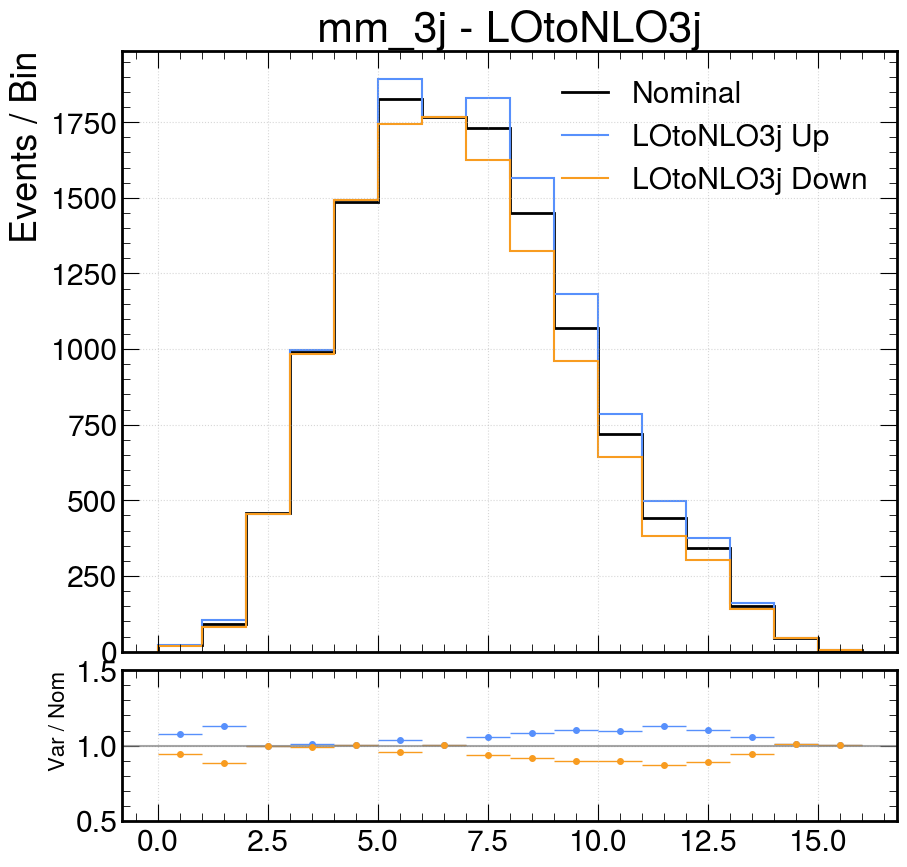

plot saved to plots_CombineHists/260519_LOtoNLO/mm_3j_LOtoNLO3j.png


In [73]:
plot_combine_variations("260519_fixLOtoNLO/TESTING-ttbar-mm_2b_3j_mllbb.root", "tt_sm", "LOtoNLO3j", "mm_3j")